In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Column names for NSL-KDD dataset
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

print(f"Total columns: {len(col_names)}")
print("\nFirst 10 column names:")
print(col_names[:10])

Total columns: 43

First 10 column names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']


In [4]:
# Load training data with column names
train_df = pd.read_csv('data/raw/KDDTrain+.txt', names=col_names)

print(f"Training set shape: {train_df.shape}")
print(f"\nFirst 5 rows:")
train_df.head()

Training set shape: (125973, 43)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
# Get basic information about the dataset
print("Dataset Info:")
print("-" * 50)
train_df.info()

print("\n" + "="*50)
print("\nBasic Statistics:")
print("-" * 50)
train_df.describe()

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64 

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


Attack Types Distribution:
--------------------------------------------------
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


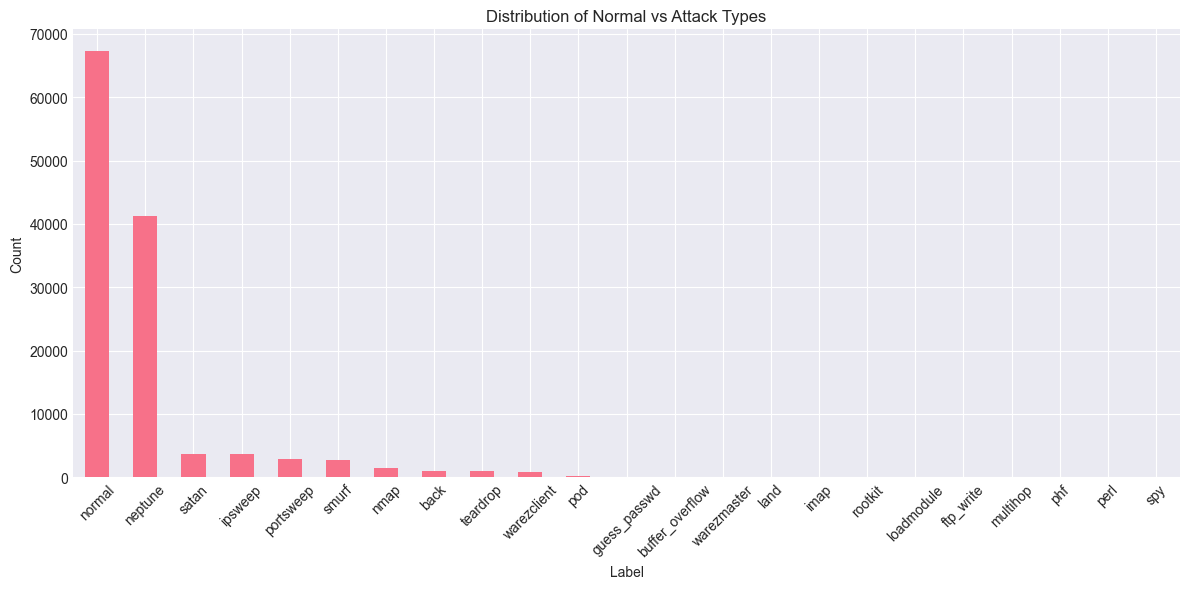


Normal connections: 67343 (53.5%)
Attack connections: 58630 (46.5%)


In [6]:
# Check what types of attacks we have
print("Attack Types Distribution:")
print("-" * 50)
print(train_df['label'].value_counts())

# Visualize it
plt.figure(figsize=(12, 6))
train_df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Normal vs Attack Types')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate percentage of normal vs attacks
normal_count = (train_df['label'] == 'normal').sum()
attack_count = (train_df['label'] != 'normal').sum()
total = len(train_df)

print("\n" + "=" * 50)
print(f"Normal connections: {normal_count} ({normal_count/total*100:.1f}%)")
print(f"Attack connections: {attack_count} ({attack_count/total*100:.1f}%)")

Protocol Types Used:
------------------------------
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


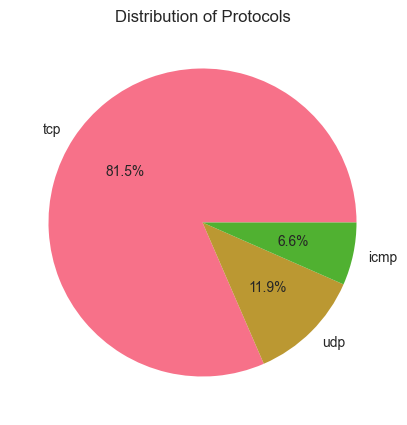


Attacks by Protocol:
------------------------------
protocol_type
tcp     49089
icmp     6982
udp      2559
Name: count, dtype: int64


In [7]:
# Check protocols used
print("Protocol Types Used:")
print("-" * 30)
print(train_df['protocol_type'].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
train_df['protocol_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Protocols')
plt.ylabel('')
plt.show()

# See which protocols have most attacks
print("\nAttacks by Protocol:")
print("-" * 30)
attack_df = train_df[train_df['label'] != 'normal']
print(attack_df['protocol_type'].value_counts())

In [5]:
# See which protocols have the most attacks
print("ATTACKS BY PROTOCOL:")
print("=" * 50)

# Create a cross-tabulation
protocol_attack = pd.crosstab(train_df['protocol_type'], 
                               train_df['label'] != 'normal', 
                               margins=True, 
                               margins_name="Total")

# Rename columns for clarity
protocol_attack.columns = ['Normal', 'Attack', 'Total']

print(protocol_attack)

# Calculate attack percentage per protocol
print("\nATTACK PERCENTAGE BY PROTOCOL:")
print("=" * 50)
protocol_pct = pd.crosstab(train_df['protocol_type'], 
                           train_df['label'] != 'normal', 
                           normalize='index') * 100
protocol_pct.columns = ['Normal %', 'Attack %']
print(protocol_pct)

ATTACKS BY PROTOCOL:


NameError: name 'train_df' is not defined

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Column names for NSL-KDD dataset
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

print(f"Total columns: {len(col_names)}")
print("\nFirst 10 column names:")
print(col_names[:10])

Total columns: 43

First 10 column names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']


In [8]:
# See which protocols have the most attacks
print("ATTACKS BY PROTOCOL:")
print("=" * 50)

# Create a cross-tabulation
protocol_attack = pd.crosstab(train_df['protocol_type'], 
                               train_df['label'] != 'normal', 
                               margins=True, 
                               margins_name="Total")

# Rename columns for clarity
protocol_attack.columns = ['Normal', 'Attack', 'Total']

print(protocol_attack)

# Calculate attack percentage per protocol
print("\nATTACK PERCENTAGE BY PROTOCOL:")
print("=" * 50)
protocol_pct = pd.crosstab(train_df['protocol_type'], 
                           train_df['label'] != 'normal', 
                           normalize='index') * 100
protocol_pct.columns = ['Normal %', 'Attack %']
print(protocol_pct)

ATTACKS BY PROTOCOL:


NameError: name 'train_df' is not defined

In [9]:
# Check what variables exist
print("Variables currently in memory:")
print("=" * 50)
print(dir())

# Specifically check for train_df
print("\nChecking for train_df:")
if 'train_df' in dir():
    print("✅ train_df EXISTS in memory")
    print(f"   Shape: {train_df.shape}")
    print(f"   First few labels: {train_df['label'].head()}")
else:
    print("❌ train_df NOT found in memory")

# Check if pandas is loaded
print("\nChecking for pandas:")
if 'pd' in dir():
    print("✅ pandas is loaded")
    print(f"   Version: {pd.__version__}")
else:
    print("❌ pandas NOT loaded")

Variables currently in memory:
['In', 'Out', 'PS1', 'REPLHooks', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'col_names', 'exit', 'get_ipython', 'get_last_command', 'is_wsl', 'np', 'open', 'original_ps1', 'pd', 'platform', 'plt', 'quit', 'sns', 'sys']

Checking for train_df:
❌ train_df NOT found in memory

Checking for pandas:
✅ pandas is loaded
   Version: 2.3.3


In [10]:
# RELOAD everything in one cell (copy-paste entire thing)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Column names
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load data
train_df = pd.read_csv('data/raw/KDDTrain+.txt', names=col_names)

print(f"✅ Data loaded! Shape: {train_df.shape}")
print(f"✅ First 5 labels: {train_df['label'].head().tolist()}")

✅ Data loaded! Shape: (125973, 43)
✅ First 5 labels: ['normal', 'normal', 'neptune', 'normal', 'normal']


In [11]:
# Simple test
print("Testing access to train_df:")
print(f"train_df type: {type(train_df)}")
print(f"First 3 protocol types: {train_df['protocol_type'].head(3).tolist()}")

Testing access to train_df:
train_df type: <class 'pandas.core.frame.DataFrame'>
First 3 protocol types: ['tcp', 'udp', 'tcp']


In [12]:
# Protocol analysis
protocol_attack = pd.crosstab(train_df['protocol_type'], 
                               train_df['label'] != 'normal', 
                               margins=True, 
                               margins_name="Total")
protocol_attack.columns = ['Normal', 'Attack', 'Total']
print(protocol_attack)

               Normal  Attack   Total
protocol_type                        
icmp             1309    6982    8291
tcp             53600   49089  102689
udp             12434    2559   14993
Total           67343   58630  125973


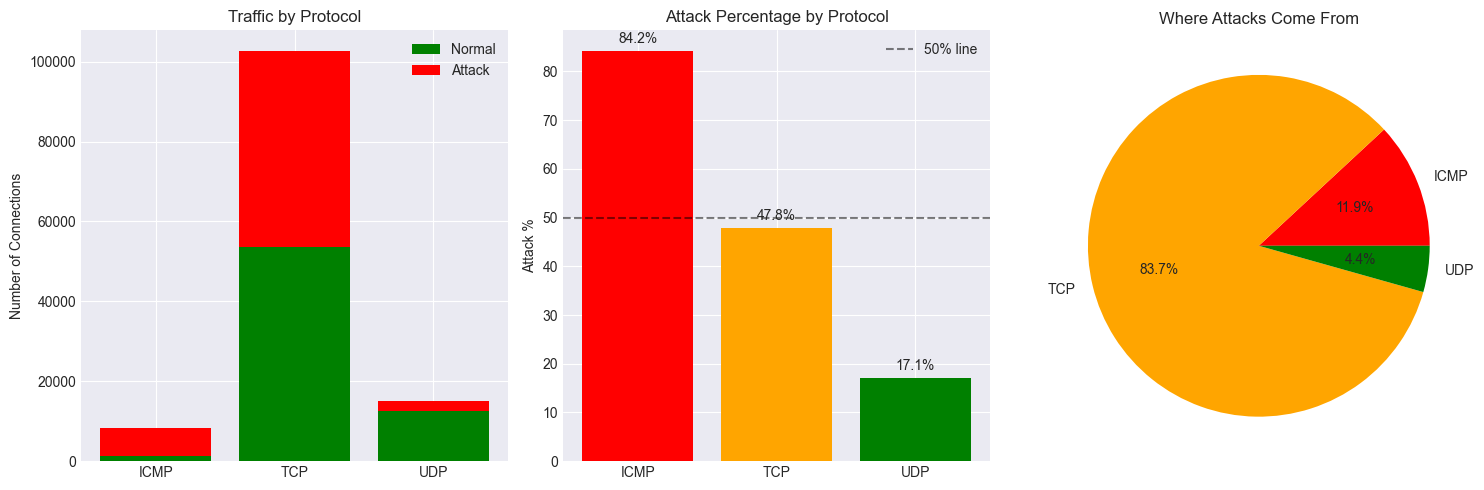

📊 Analysis complete! Visualization saved to exports/plots/


In [15]:
# Visualize attack distribution by protocol
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Stacked bar chart
protocols = ['ICMP', 'TCP', 'UDP']
normal_counts = [1309, 53600, 12434]
attack_counts = [6982, 49089, 2559]

axes[0].bar(protocols, normal_counts, label='Normal', color='green')
axes[0].bar(protocols, attack_counts, bottom=normal_counts, label='Attack', color='red')
axes[0].set_title('Traffic by Protocol')
axes[0].set_ylabel('Number of Connections')
axes[0].legend()

# 2. Attack percentage bar chart
attack_pct = [6982/8291*100, 49089/102689*100, 2559/14993*100]
colors = ['red' if p > 80 else 'orange' if p > 40 else 'green' for p in attack_pct]
bars = axes[1].bar(protocols, attack_pct, color=colors)
axes[1].set_title('Attack Percentage by Protocol')
axes[1].set_ylabel('Attack %')
axes[1].axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50% line')
axes[1].legend()

# Add percentage labels on bars
for bar, pct in zip(bars, attack_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{pct:.1f}%', ha='center', va='bottom')

# 3. Pie chart of attacks by protocol
attack_sources = [6982, 49089, 2559]
axes[2].pie(attack_sources, labels=protocols, autopct='%1.1f%%', 
           colors=['red', 'orange', 'green'])
axes[2].set_title('Where Attacks Come From')

plt.tight_layout()
plt.savefig('exports/plots/protocol_attack_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Analysis complete! Visualization saved to exports/plots/")

In [14]:
import os

# Create the exports/plots folder if it doesn't exist
os.makedirs('exports/plots', exist_ok=True)
print("✅ Created folder: exports/plots/")

# Also create other useful folders
os.makedirs('exports/reports', exist_ok=True)
os.makedirs('exports/notebooks', exist_ok=True)
print("✅ Created additional export folders")

✅ Created folder: exports/plots/
✅ Created additional export folders
